# Ein Modell für alle Messdatensätze

! XBG wird ausgeschlossen

# Vorbereitung

In [113]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Laden der CSV-Dateien in separate DataFrames
df_1 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Heart_Logistic_Regression.csv')
df_2 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Heart_GaussianNB.csv')
df_3 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Heart_DecisionTree.csv')

df_4 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_RandomForest.csv')
df_5 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_LogisticRegression.csv')
df_6 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_KNN.csv')
df_8 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_GaussianNB.csv')
df_9 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_DecisionTree.csv')

df_10 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Bank_RandomForest.csv')
df_11 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Bank_LogisticRegression.csv')
df_12 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_bank_KNN.csv')
df_13 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Bank_GaussianNB.csv')
df_14 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_BANK_DCT.csv')

# Alle DataFrames in eine Liste einfügen
dfs = [df_1, df_2, df_3, df_4, df_5, df_6, df_8, df_9, df_10, df_11, df_12, df_13, df_14]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
 # Definieren der Feature Typen
feature_types = {
    'Diabetes_binary': 'kategorisch',
    'HighBP': 'kategorisch',
    'HighChol': 'kategorisch',
    'CholCheck': 'kategorisch',
    'BMI': 'numerisch',
    'Smoker': 'kategorisch',
    'Stroke': 'kategorisch',
    'HeartDiseaseorAttack': 'kategorisch',
    'PhysActivity': 'kategorisch',
    'Fruits': 'kategorisch',
    'Veggies': 'kategorisch',
    'HvyAlcoholConsump': 'kategorisch',
    'AnyHealthcare': 'kategorisch',
    'NoDocbcCost': 'kategorisch',
    'GenHlth': 'numerisch',
    'MentHlth': 'numerisch',
    'PhysHlth': 'numerisch',
    'DiffWalk': 'kategorisch',
    'Sex': 'kategorisch',
    'Age': 'numerisch',
    'Education': 'numerisch',
    'Income': 'numerisch',
    'age': 'numerisch',
    'job': 'kategorisch',
    'marital': 'kategorisch',
    'education': 'kategorisch',
    'default': 'kategorisch',
    'balance': 'numerisch',
    'housing': 'kategorisch',
    'loan': 'kategorisch',
    'contact': 'kategorisch',
    'day_of_week': 'kategorisch',
    'month': 'kategorisch',
    'duration': 'numerisch',
    'pdays': 'numerisch',
    'previous': 'numerisch',
    'poutcome': 'kategorisch',
    'HeartDisease': 'kategorisch',
    'BMI': 'numerisch',
    'Smoking': 'kategorisch',
    'AlcoholDrinking': 'kategorisch',
    'Stroke': 'kategorisch',
    'PhysicalHealth': 'numerisch',
    'MentalHealth': 'numerisch',
    'DiffWalking': 'kategorisch',
    'Sex': 'kategorisch',
    'AgeCategory': 'kategorisch',
    'Race': 'kategorisch',
    'Diabetic': 'kategorisch',
    'PhysicalActivity': 'kategorisch',
    'GenHealth': 'kategorisch',
    'SleepTime': 'numerisch',
    'Asthma': 'kategorisch',
    'KidneyDisease': 'kategorisch',
    'SkinCancer': 'kategorisch'
}

In [115]:
df_1.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,gpu_model,longitude,latitude,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names
0,2023-11-17T08:30:09,LogisticRegression_17_features_reduced_by_0_pe...,caf57cf5-b259-4a2c-bc67-bea00e2a898c,0.445057,7.999063e-07,0.000002,42.5,0.0,4.754376,0.000005,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,0,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."
1,2023-11-17T08:30:12,LogisticRegression_17_features_reduced_by_20_p...,6ae977a5-b2fa-449c-9036-12467aec2fd5,0.365585,6.496404e-07,0.000002,42.5,0.0,4.754376,0.000004,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,20,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."
2,2023-11-17T08:30:14,LogisticRegression_17_features_reduced_by_40_p...,0830ffc0-0553-48b3-8434-e33dd6eb1be6,0.305748,5.390057e-07,0.000002,42.5,0.0,4.754376,0.000004,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,40,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."
3,2023-11-17T08:30:17,LogisticRegression_17_features_reduced_by_60_p...,6eb9c17f-25b6-4576-9073-0beaba830ad3,0.278265,4.933792e-07,0.000002,42.5,0.0,4.754376,0.000003,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,60,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."
4,2023-11-17T08:30:19,LogisticRegression_17_features_reduced_by_80_p...,9e90146c-6328-4cff-9a6e-4d6f266fa299,0.227904,3.947965e-07,0.000002,42.5,0.0,4.754376,0.000003,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,80,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."


In [116]:
# Mappen der Features auf die Daten
dataframes = [df_1, df_2, df_3, df_4, df_5, df_6, df_8, df_9, df_10, df_11, df_12, df_13, df_14]

for df in dataframes:
  df['num_num_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
  df['num_cat_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

# Ermitteln, wie of ein feature vorgekommen ist

df['feature_names'] = df['feature_names'].str.split(', ')

feature_counts = {}

# Iteriere über jedes DataFrame in der Liste
for df in dataframes:
    df['feature_names'] = df['feature_names'].str.split(', ')
    for index, row in df.iterrows():
        features = row['feature_names']
        if isinstance(features, list):
            for feature in features:
                if feature in feature_counts:
                    feature_counts[feature] += 1
                else:
                    feature_counts[feature] = 1

In [117]:
#Heart Daten satz = 320.000 Diabetes Datensatz = 250.000 Bank Datensatz = 45.211

# Richtige Anzahl der Samples in Daten eintragen


df_1['number_of_instances'] = 320000 * (1 - df_1['reduction_percentage'] / 100)
df_2['number_of_instances'] =  320000 * (1 - df_2['reduction_percentage'] / 100)
df_3['number_of_instances'] =  320000 * (1 - df_3['reduction_percentage'] / 100)

df_4['number_of_instances'] = 250000 * (1 - df_4['reduction_percentage'] / 100)
df_5['number_of_instances'] = 250000 * (1 - df_5['reduction_percentage'] / 100)
df_6['number_of_instances'] = 250000 * (1 - df_6['reduction_percentage'] / 100)
df_8['number_of_instances'] = 250000 * (1 - df_8['reduction_percentage'] / 100)
df_9['number_of_instances'] = 250000 * (1 - df_9['reduction_percentage'] / 100)

df_10['number_of_instances'] = 45211 * (1 - df_10['reduction_percentage'] / 100)
df_11['number_of_instances'] = 45211 * (1 - df_11['reduction_percentage'] / 100)
df_12['number_of_instances'] = 45211 * (1 - df_12['reduction_percentage'] / 100)
df_13['number_of_instances'] = 45211 * (1 - df_13['reduction_percentage'] / 100)
df_14['number_of_instances'] = 45211 * (1 - df_14['reduction_percentage'] / 100)


In [118]:
df_14.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features,number_of_instances
0,2023-11-12T13:00:24,DecisionTree_19_features_reduced_by_0_percent0,b089c878-b567-4b5e-ae70-03abeaade72a,0.299119,1.504002e-06,0.000005,42.5,0.0,4.754379,3.483172e-06,...,12.678345,machine,N,1.0,19,0,NaN,3,10,45211.0
1,2023-11-12T13:00:26,DecisionTree_19_features_reduced_by_20_percent0,770b3004-eee9-4bd5-9821-dccecd4d942d,0.171267,8.497686e-07,0.000005,42.5,0.0,4.754379,1.969609e-06,...,12.678345,machine,N,1.0,19,20,NaN,3,10,36168.8
2,2023-11-12T13:00:28,DecisionTree_19_features_reduced_by_40_percent0,2b72544f-d62a-4ab4-a940-c8e159941119,0.132989,6.234077e-07,0.000005,42.5,0.0,4.754379,1.444711e-06,...,12.678345,machine,N,1.0,19,40,NaN,3,10,27126.6
3,2023-11-12T13:00:30,DecisionTree_19_features_reduced_by_60_percent0,20cb3715-3a20-479f-9b16-aa9e51ecb21f,0.093119,4.414532e-07,0.000005,42.5,0.0,4.754379,1.024619e-06,...,12.678345,machine,N,1.0,19,60,NaN,3,10,18084.4
4,2023-11-12T13:00:31,DecisionTree_19_features_reduced_by_80_percent0,a27f9f39-c84b-4842-a897-92226f7946d9,0.047154,2.168466e-07,0.000005,42.5,0.0,4.754379,5.048775e-07,...,12.678345,machine,N,1.0,19,80,NaN,3,10,9042.2


In [119]:
# Hinzufügen von dem verwendeten Model
model_names = {
    'random_forest': [df_4, df_10],
    'logistic_regression': [df_1, df_5, df_11],
    'knn': [df_6, df_12],
    'gaussian_nb': [df_2, df_8, df_13],
    'decision_tree': [df_3, df_9, df_14]
}

for model_name, dfs in model_names.items():
    for df in dfs:
        df.insert(0, 'model', model_name)

In [120]:
df = pd.concat([df_1, df_2, df_3, df_4, df_5, df_6, df_8, df_9, df_10, df_11, df_12, df_13, df_14])

In [121]:
df.head()

,model,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features,number_of_instances
0,logistic_regression,2023-11-17T08:30:09,LogisticRegression_17_features_reduced_by_0_pe...,caf57cf5-b259-4a2c-bc67-bea00e2a898c,0.445057,7.999063e-07,0.000002,42.5,0.0,4.754376,...,12.678337,machine,N,1.0,17,0,"[Smoking, BMI, Sex, Diabetic, AlcoholDrinking,...",4,13,320000.0
1,logistic_regression,2023-11-17T08:30:12,LogisticRegression_17_features_reduced_by_20_p...,6ae977a5-b2fa-449c-9036-12467aec2fd5,0.365585,6.496404e-07,0.000002,42.5,0.0,4.754376,...,12.678337,machine,N,1.0,17,20,"[Smoking, BMI, Sex, Diabetic, AlcoholDrinking,...",4,13,256000.0
2,logistic_regression,2023-11-17T08:30:14,LogisticRegression_17_features_reduced_by_40_p...,0830ffc0-0553-48b3-8434-e33dd6eb1be6,0.305748,5.390057e-07,0.000002,42.5,0.0,4.754376,...,12.678337,machine,N,1.0,17,40,"[Smoking, BMI, Sex, Diabetic, AlcoholDrinking,...",4,13,192000.0
3,logistic_regression,2023-11-17T08:30:17,LogisticRegression_17_features_reduced_by_60_p...,6eb9c17f-25b6-4576-9073-0beaba830ad3,0.278265,4.933792e-07,0.000002,42.5,0.0,4.754376,...,12.678337,machine,N,1.0,17,60,"[Smoking, BMI, Sex, Diabetic, AlcoholDrinking,...",4,13,128000.0
4,logistic_regression,2023-11-17T08:30:19,LogisticRegression_17_features_reduced_by_80_p...,9e90146c-6328-4cff-9a6e-4d6f266fa299,0.227904,3.947965e-07,0.000002,42.5,0.0,4.754376,...,12.678337,machine,N,1.0,17,80,"[Smoking, BMI, Sex, Diabetic, AlcoholDrinking,...",4,13,64000.0


In [122]:
# Reduzieren der Eingabeparams für das Modell und Analyse
selected_columns = ['energy_consumed', 'num_num_features', 'num_cat_features', 'number_of_instances', 'model']

df = df[selected_columns]

In [123]:
df.head()

,energy_consumed,num_num_features,num_cat_features,number_of_instances,model
0,0.000006,4,13,320000.0,logistic_regression
1,0.000005,4,13,256000.0,logistic_regression
2,0.000004,4,13,192000.0,logistic_regression
3,0.000004,4,13,128000.0,logistic_regression
4,0.000003,4,13,64000.0,logistic_regression


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12550 entries, 0 to 949
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   energy_consumed      12550 non-null  float64
 1   num_num_features     12550 non-null  int64  
 2   num_cat_features     12550 non-null  int64  
 3   number_of_instances  12550 non-null  float64
 4   model                12550 non-null  object 
dtypes: float64(2), int64(2), object(1)
memory usage: 588.3+ KB


In [125]:
df.isna().sum()

energy_consumed        0
num_num_features       0
num_cat_features       0
number_of_instances    0
model                  0
dtype: int64

In [126]:
# Convert strings to categories
pd.api.types.is_string_dtype(df["model"])

True

In [127]:
for label, content in df.items():
    if pd.api.types.is_string_dtype(content):
        df[label] = content.astype("category").cat.as_ordered()

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12550 entries, 0 to 949
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   energy_consumed      12550 non-null  float64 
 1   num_num_features     12550 non-null  int64   
 2   num_cat_features     12550 non-null  int64   
 3   number_of_instances  12550 non-null  float64 
 4   model                12550 non-null  category
dtypes: category(1), float64(2), int64(2)
memory usage: 502.7 KB


In [129]:
df.model.cat.categories

Index(['decision_tree', 'gaussian_nb', 'knn', 'logistic_regression',
       'random_forest'],
      dtype='object')

In [130]:
df.model.cat.codes

0      3
1      3
2      3
3      3
4      3
      ..
945    0
946    0
947    0
948    0
949    0
Length: 12550, dtype: int8

In [131]:
# Turn categorical variables into numbers
for label, content in df.items():
    # Check columns which *aren't* numeric
    if not pd.api.types.is_numeric_dtype(content):
        # We add the +1 because pandas encodes missing categories as -1
        df[label] = pd.Categorical(content).codes+1

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12550 entries, 0 to 949
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   energy_consumed      12550 non-null  float64
 1   num_num_features     12550 non-null  int64  
 2   num_cat_features     12550 non-null  int64  
 3   number_of_instances  12550 non-null  float64
 4   model                12550 non-null  int8   
dtypes: float64(2), int64(2), int8(1)
memory usage: 502.5 KB


In [133]:
df.head()

,energy_consumed,num_num_features,num_cat_features,number_of_instances,model
0,0.000006,4,13,320000.0,4
1,0.000005,4,13,256000.0,4
2,0.000004,4,13,192000.0,4
3,0.000004,4,13,128000.0,4
4,0.000003,4,13,64000.0,4


In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_temp = df


X = df_temp.drop(['energy_consumed'], axis=1)  # Features
y = df_temp['energy_consumed']  # Zielvariable

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [135]:
X_train

array([[-0.80211217,  0.13797511,  0.17376362, -0.61414712],
       [ 0.2287642 ,  0.13797511, -0.13085573,  0.09622582],
       [-1.31755035, -1.44821208, -0.8252921 ,  1.51697168],
       ...,
       [ 1.77507875,  1.98852684,  1.50103364,  0.09622582],
       [ 0.2287642 ,  1.45979778,  2.26258202, -0.61414712],
       [-1.31755035, -1.44821208,  1.50103364, -1.32452005]])

# Model Training


In [136]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [139]:
# Change max samples in RandomForestRegressor
model = RandomForestRegressor()

In [140]:
model.fit(X_train, y_train)

RandomForestRegressor()

In [141]:
# find hyperparameters
ideal_model = RandomForestRegressor(n_estimators=90,
                                    min_samples_leaf=1,
                                    min_samples_split=14,
                                    max_features=0.5,
                                    n_jobs=-1,
                                    max_samples=None)
ideal_model.fit(X_train, y_train)

RandomForestRegressor(max_features=0.5, min_samples_split=14, n_estimators=90,
                      n_jobs=-1)

In [144]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Funktion zum Ergebnisse predicten
def get_predictions(regressor, X_test, X_train, y_test):
  predictions = regressor.predict(X_test)

  plt.scatter(y_test, predictions)
  regression_line = np.polyfit(y_test, predictions, 1)
  plt.plot(y_test, np.polyval(regression_line, y_test), color='red')
  plt.show()

  residuals = y_test - predictions
  plt.scatter(predictions, residuals)
  plt.axhline(y=0, color='red', linestyle='--')
  plt.xlabel("Vorhersagen")
  plt.ylabel("Residuen")
  plt.title("Residualplot")

  plt.show()

  r2 = r2_score(y_test, predictions)
  rmse = mean_squared_error(y_test, predictions, squared=False)
  mae = mean_absolute_error(y_test, predictions)
  mse = mean_squared_error(y_test, predictions)

  print(f'R2 Score: {r2}')
  print(f'RMSE: {rmse}')
  print(f'MAE: {mae}')
  print(f'MSE: {mse}')

  return r2

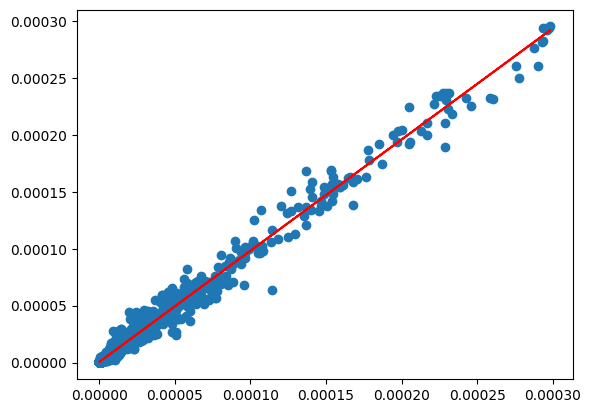

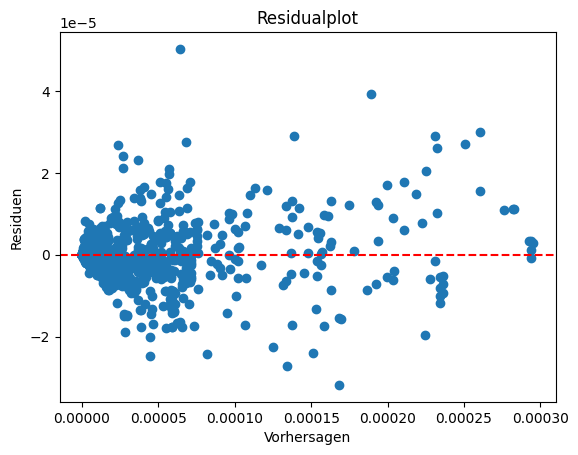

R2 Score: 0.9875074275224712
RMSE: 4.325474504228848e-06
MAE: 1.8881053366713755e-06
MSE: 1.8709729686733802e-11


0.9875074275224712

In [147]:
get_predictions(ideal_model, X_test, X_train, y_test)